In [1]:
import torch
print("¿GPU Activada?:", torch.cuda.is_available())

¿GPU Activada?: True


CELDA 1: RECEPCIÓN

In [2]:
import os
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from google.colab import drive

# 1. Conectar Google Drive
drive.mount('/content/drive')

# 2. Rutas
PROJECT_DIR = '/content/drive/MyDrive/Proyecto_IA'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Dispositivo: {DEVICE}')

PATHS = {
    split: {
        'cxr'    : os.path.join(PROJECT_DIR, split, f'cxr_{split}.npy'),
        'ecg'    : os.path.join(PROJECT_DIR, split, f'ecg_{split}.npy'),
        'labs'   : os.path.join(PROJECT_DIR, split, f'labs_percentiles_{split}.npy'),
        'hadm_id': os.path.join(PROJECT_DIR, split, f'hadm_id_{split}.npy'),
        'csv'    : os.path.join(PROJECT_DIR, f'{split}.csv'),
    }
    for split in ['train', 'val', 'test']
}

TARGET_LABELS = ['Atelectasis', 'Cardiomegaly', 'Edema', 'Pleural Effusion']
BATCH_SIZE = 16

# 3. Dataset (Optimizador de memoria)
class SymileMultimodalDataset(Dataset):
    def __init__(self, split, paths, target_labels):
        super().__init__()
        self.target_labels = target_labels
        print(f'[{split.upper()}] Cargando tensores...')

        self.cxr  = np.load(paths['cxr'], mmap_mode='r', allow_pickle=False)
        self.ecg  = np.load(paths['ecg'], mmap_mode='r', allow_pickle=False)
        self.labs = np.load(paths['labs'], allow_pickle=False).astype(np.float32)
        self.hadm_ids = np.load(paths['hadm_id'], allow_pickle=False)

        nan_mask = np.isnan(self.labs)
        self.labs[nan_mask] = 0.5

        df = pd.read_csv(paths['csv'])
        df = df.drop_duplicates(subset=['hadm_id']).reset_index(drop=True)

        for col in self.target_labels:
            df[col] = (df[col] == 1.0).astype(np.float32) if col in df.columns else 0.0

        if 'No Finding' in df.columns:
            mask_nf = (df['No Finding'] == 1.0)
            df.loc[mask_nf, self.target_labels] = 0.0

        df_idx = df.set_index('hadm_id')
        valid_idx, labels_list = [], []

        for ti, h in enumerate(self.hadm_ids):
            if int(h) in df_idx.index:
                labels_list.append(df_idx.loc[int(h), self.target_labels].values.astype(np.float32))
                valid_idx.append(ti)

        self.valid_indices = np.array(valid_idx)
        self.labels = np.array(labels_list, dtype=np.float32)
        print(f'  Muestras válidas: {len(valid_idx)}')

    def __len__(self): return len(self.valid_indices)

    def __getitem__(self, idx):
        ti = self.valid_indices[idx]
        cxr_t = torch.from_numpy(np.array(self.cxr[ti], dtype=np.float32))
        if cxr_t.max() > 1.0: cxr_t = cxr_t / 255.0
        return {
            'cxr': cxr_t,
            'ecg': torch.from_numpy(np.array(self.ecg[ti], dtype=np.float32)),
            'labs': torch.from_numpy(self.labs[ti]),
            'label': torch.tensor(self.labels[idx], dtype=torch.float32)
        }

train_dataset = SymileMultimodalDataset('train', PATHS['train'], TARGET_LABELS)
val_dataset   = SymileMultimodalDataset('val',   PATHS['val'],   TARGET_LABELS)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print("✅ Datos montados exitosamente en Colab.")

Mounted at /content/drive
✅ Dispositivo: cuda
[TRAIN] Cargando tensores...
  Muestras válidas: 10000
[VAL] Cargando tensores...
  Muestras válidas: 750
✅ Datos montados exitosamente en Colab.


CELDA 2: ENTRENAMIENTO

In [3]:
!pip install timm -q
import timm
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as T
import time
from sklearn.metrics import roc_auc_score
import numpy as np
import torch

# --- 1. ARQUITECTURA TRANSFORMER ---
class CXRTransformerTower(nn.Module):
    def __init__(self, embed_dim=128):
        super().__init__()
        self.vit = timm.create_model('vit_base_patch16_224', pretrained=True, img_size=320, num_classes=0)
        self.proj = nn.Sequential(nn.Linear(768, embed_dim), nn.LayerNorm(embed_dim))
    def forward(self, x): return self.proj(self.vit(x))

class ECGTransformerTower(nn.Module):
    def __init__(self, embed_dim=128):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(12, 32, 15, 4, 7), nn.GELU(),
            nn.Conv1d(32, 64, 7, 4, 3), nn.GELU(),
            nn.Conv1d(64, embed_dim, 5, 4, 2), nn.GELU(),
            nn.Conv1d(embed_dim, embed_dim, 3, 2, 1)
        )
        self.transformer = nn.TransformerEncoder(nn.TransformerEncoderLayer(embed_dim, 4, embed_dim*2, batch_first=True), 2)
        self.gap = nn.AdaptiveAvgPool1d(1)
    def forward(self, x):
        if x.dim() == 4: x = x.squeeze(1).permute(0, 2, 1)
        x = self.cnn(x).permute(0, 2, 1)
        x = self.transformer(x).permute(0, 2, 1)
        return self.gap(x).squeeze(-1)

class LabsTower(nn.Module):
    def __init__(self, embed_dim=128):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(50, 256), nn.LayerNorm(256), nn.GELU(), nn.Linear(256, embed_dim), nn.LayerNorm(embed_dim))
    def forward(self, x): return self.net(x)

class MultimodalTransformerSymile(nn.Module):
    def __init__(self, embed_dim=128, num_classes=4):
        super().__init__()
        self.cxr_tower, self.ecg_tower, self.labs_tower = CXRTransformerTower(embed_dim), ECGTransformerTower(embed_dim), LabsTower(embed_dim)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.modality_embed = nn.Parameter(torch.randn(1, 4, embed_dim))
        self.fusion = nn.TransformerEncoder(nn.TransformerEncoderLayer(embed_dim, 4, 256, batch_first=True), 2)
        self.classifier = nn.Sequential(nn.Linear(embed_dim, 64), nn.GELU(), nn.Linear(64, num_classes))
    def forward(self, cxr, ecg, labs):
        B = cxr.size(0)
        tokens = torch.stack([self.cxr_tower(cxr), self.ecg_tower(ecg), self.labs_tower(labs)], dim=1)
        x = torch.cat((self.cls_token.expand(B, -1, -1), tokens), dim=1) + self.modality_embed
        return self.classifier(self.fusion(x)[:, 0, :])

# --- 2. CONFIGURACIÓN MEJORADA ---
model = MultimodalTransformerSymile().to(DEVICE)
POS_WEIGHT = torch.tensor([2.4880, 1.9886, 3.8379, 1.7640]).to(DEVICE)

# Normalizador ImageNet
normalize_cxr = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

class FocalBCELoss(nn.Module):
    def forward(self, logits, targets):
        p = torch.sigmoid(logits)
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        focal = (1 - torch.where(targets==1, p, 1-p))**2.0 * bce
        w = torch.where(targets==1, POS_WEIGHT.unsqueeze(0).expand_as(targets), torch.ones_like(targets))
        return (focal * w).mean()

criterion = FocalBCELoss()

vit_params = []
other_params = []
for name, param in model.named_parameters():
    if 'vit' in name:
        vit_params.append(param)
    else:
        other_params.append(param)

optimizer = optim.AdamW([
    {'params': vit_params, 'lr': 3e-5},
    {'params': other_params, 'lr': 3e-4}
], weight_decay=1e-4)

# --- 3. CICLO DE ENTRENAMIENTO ---
NUM_EPOCHS = 15
best_auc = 0.0

print(f'🚀 Iniciando Entrenamiento Corregido en Colab (T4 GPU)')
for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    t0 = time.time()
    for batch in train_loader:
        cxr = batch['cxr'].to(DEVICE)

        # --- BLINDAJE CONTRA ERRORES DE CANALES ---
        if cxr.dim() == 3: cxr = cxr.unsqueeze(1) # Si viene (Batch, H, W) -> (Batch, 1, H, W)
        if cxr.size(1) == 1: cxr = cxr.repeat(1, 3, 1, 1) # Si viene en 1 canal, lo triplica a 3
        # ------------------------------------------

        cxr_norm = normalize_cxr(cxr)

        logits = model(cxr_norm, batch['ecg'].to(DEVICE), batch['labs'].to(DEVICE))
        loss = criterion(logits, batch['label'].to(DEVICE))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for batch in val_loader:
            lbl = batch['label'].to(DEVICE)
            cxr = batch['cxr'].to(DEVICE)

            # --- BLINDAJE EN VALIDACIÓN ---
            if cxr.dim() == 3: cxr = cxr.unsqueeze(1)
            if cxr.size(1) == 1: cxr = cxr.repeat(1, 3, 1, 1)
            cxr_norm = normalize_cxr(cxr)

            probs = torch.sigmoid(model(cxr_norm, batch['ecg'].to(DEVICE), batch['labs'].to(DEVICE)))
            all_probs.append(probs.cpu().numpy())
            all_labels.append(lbl.cpu().numpy())

    probs, labels = np.vstack(all_probs), np.vstack(all_labels)
    aucs = [roc_auc_score(labels[:, i], probs[:, i]) for i in range(4) if len(np.unique(labels[:, i])) > 1]
    mean_auc = np.mean(aucs) if aucs else 0

    print(f'📌 Epoch {epoch}/{NUM_EPOCHS} | Val AUC (mean): {mean_auc:.4f} | Tiempo: {(time.time()-t0)/60:.1f} min')

    if mean_auc > best_auc:
        best_auc = mean_auc
        torch.save(model.state_dict(), '/content/drive/MyDrive/Proyecto_IA/best_transformer.pt')
        print(f'  💾 ✅ Modelo guardado en tu Drive!')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

🚀 Iniciando Entrenamiento Corregido en Colab (T4 GPU)
📌 Epoch 1/15 | Val AUC (mean): 0.6132 | Tiempo: 14.9 min
  💾 ✅ Modelo guardado en tu Drive!
📌 Epoch 2/15 | Val AUC (mean): 0.6161 | Tiempo: 13.0 min
  💾 ✅ Modelo guardado en tu Drive!
📌 Epoch 3/15 | Val AUC (mean): 0.6264 | Tiempo: 13.1 min
  💾 ✅ Modelo guardado en tu Drive!
📌 Epoch 4/15 | Val AUC (mean): 0.6315 | Tiempo: 13.1 min
  💾 ✅ Modelo guardado en tu Drive!
📌 Epoch 5/15 | Val AUC (mean): 0.6316 | Tiempo: 13.1 min
  💾 ✅ Modelo guardado en tu Drive!
📌 Epoch 6/15 | Val AUC (mean): 0.6210 | Tiempo: 13.1 min
📌 Epoch 7/15 | Val AUC (mean): 0.6319 | Tiempo: 13.0 min
  💾 ✅ Modelo guardado en tu Drive!
📌 Epoch 8/15 | Val AUC (mean): 0.6342 | Tiempo: 13.1 min
  💾 ✅ Modelo guardado en tu Drive!
📌 Epoch 9/15 | Val AUC (mean): 0.6320 | Tiempo: 13.1 min
📌 Epoch 10/15 | Val AUC (mean): 0.6313 | Tiempo: 13.0 min
📌 Epoch 11/15 | Val AUC (mean): 0.6269 | Tiempo: 13.0 min
📌 Epoch 12/15 | Val AUC (mean): 0.6273 | Tiempo: 13.1 min
📌 Epoch 13/15 

CELDA 3: MÉTRICAS

📊 Loading the best model to generate the Global Metrics Report...

Pathology            | AUC      | F1-Score   | Precision  | Recall  
---------------------------------------------------------------------------
Atelectasis          | 0.5902   | 0.4363     | 0.3400     | 0.6089
Cardiomegaly         | 0.6153   | 0.4854     | 0.4750     | 0.4963
Edema                | 0.6484   | 0.3912     | 0.2776     | 0.6622
Pleural Effusion     | 0.6828   | 0.5515     | 0.4603     | 0.6877


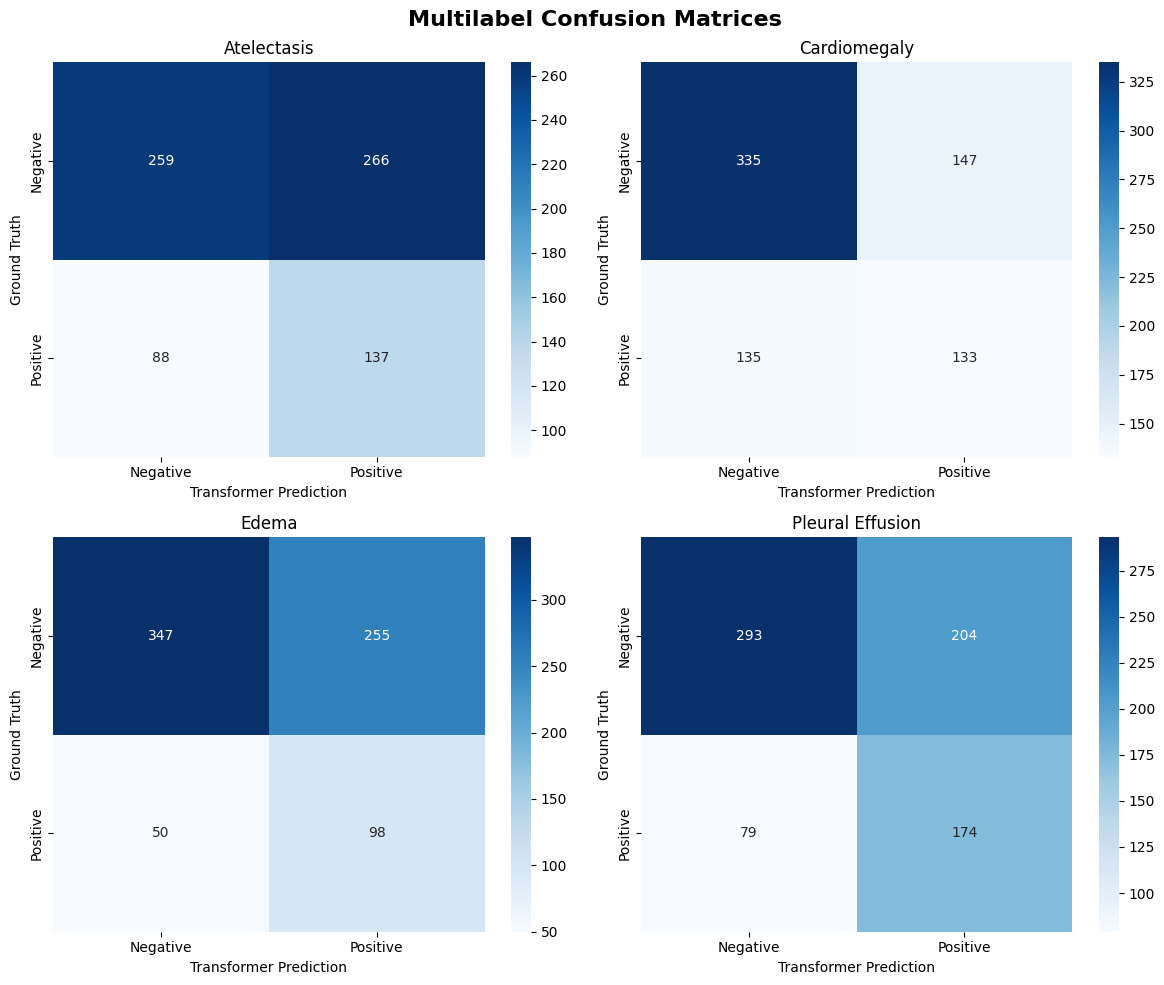

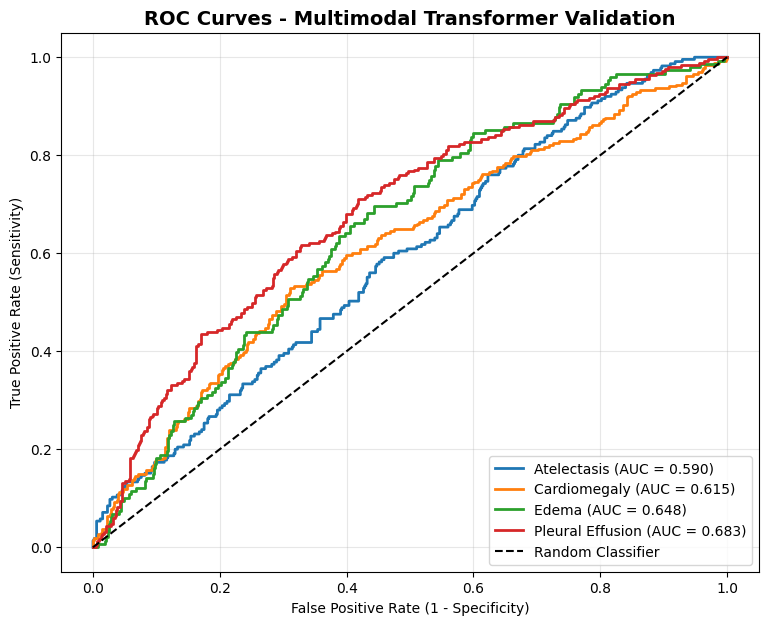

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, precision_recall_fscore_support, multilabel_confusion_matrix, accuracy_score
import numpy as np
import torch

print("📊 Loading the best model to generate the Global Metrics Report...")
model.load_state_dict(torch.load('/content/drive/MyDrive/Proyecto_IA/best_transformer.pt'))
model.eval()

all_probs = []
all_labels = []

# Evaluar sobre todo el set de validación
with torch.no_grad():
    for batch in val_loader:
        cxr = batch['cxr'].to(DEVICE)

        # --- BLINDAJE DE CANALES Y NORMALIZACIÓN ---
        if cxr.dim() == 3: cxr = cxr.unsqueeze(1)
        if cxr.size(1) == 1: cxr = cxr.repeat(1, 3, 1, 1)
        cxr_norm = normalize_cxr(cxr)
        # -------------------------------------------

        ecg = batch['ecg'].to(DEVICE)
        labs = batch['labs'].to(DEVICE)
        labels = batch['label'].to(DEVICE)

        logits = model(cxr_norm, ecg, labs)
        probs = torch.sigmoid(logits)

        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

probs = np.vstack(all_probs)
labels = np.vstack(all_labels)
preds = (probs >= 0.5).astype(int)

# 1. Métrica Cuantitativa: Tabla de F1, Precisión, Recall y AUC
prec, rec, f1, _ = precision_recall_fscore_support(labels, preds, average=None, zero_division=0)
print("\n" + "="*75)
print(f"{'Pathology':<20} | {'AUC':<8} | {'F1-Score':<10} | {'Precision':<10} | {'Recall':<8}")
print("-" * 75)
for i, lbl in enumerate(TARGET_LABELS):
    auc = roc_auc_score(labels[:, i], probs[:, i])
    print(f"{lbl:<20} | {auc:.4f}   | {f1[i]:.4f}     | {prec[i]:.4f}     | {rec[i]:.4f}")
print("="*75)

# 2. Matrices de Confusión (4 subgráficos para multietiqueta)
mcm = multilabel_confusion_matrix(labels, preds)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Multilabel Confusion Matrices', fontsize=16, fontweight='bold')
for i, (ax, lbl) in enumerate(zip(axes.flatten(), TARGET_LABELS)):
    sns.heatmap(mcm[i], annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
    ax.set_title(f'{lbl}')
    ax.set_ylabel('Ground Truth')
    ax.set_xlabel('Transformer Prediction')
plt.tight_layout()
plt.show()

# 3. Curvas ROC
plt.figure(figsize=(9, 7))
for i, lbl in enumerate(TARGET_LABELS):
    fpr, tpr, _ = roc_curve(labels[:, i], probs[:, i])
    auc = roc_auc_score(labels[:, i], probs[:, i])
    plt.plot(fpr, tpr, lw=2, label=f'{lbl} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.title('ROC Curves - Multimodal Transformer Validation', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

CELDA 4: VISUAL XAI

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 64.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
🔍 Generating Visual XAI Dashboard (ViT Attention Maps)...


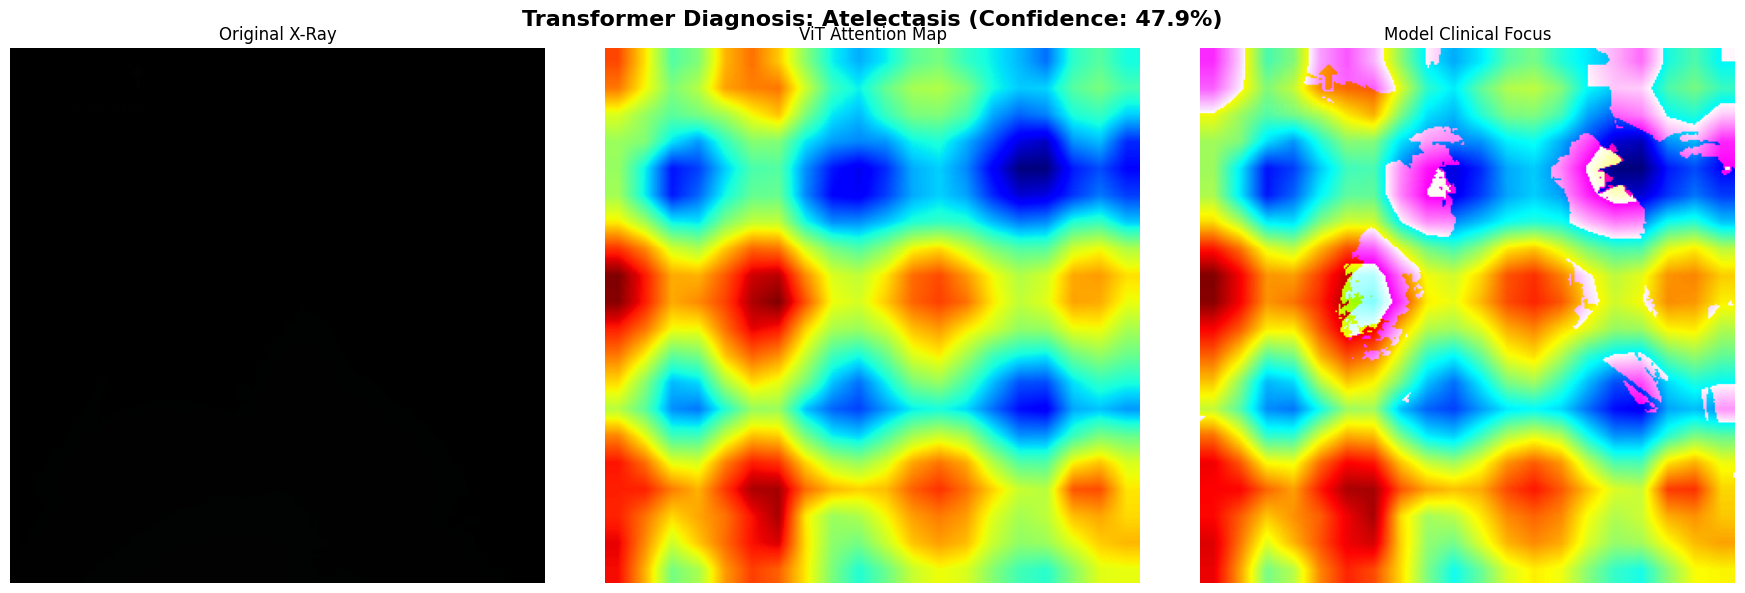


📊 Probability Breakdown:
 - Atelectasis: 47.9% (Ground Truth: NEGATIVE)
 - Cardiomegaly: 45.3% (Ground Truth: NEGATIVE)
 - Edema: 41.8% (Ground Truth: NEGATIVE)
 - Pleural Effusion: 42.3% (Ground Truth: NEGATIVE)


In [5]:
!pip install grad-cam matplotlib -q
import matplotlib.pyplot as plt
import random
import numpy as np
import torch
import torch.nn as nn
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# 1. Envolver el modelo para aislar la Radiografía
class CXR_XAI_Wrapper(nn.Module):
    def __init__(self, full_model, fixed_ecg, fixed_labs):
        super().__init__()
        self.model = full_model
        self.ecg = fixed_ecg
        self.labs = fixed_labs
    def forward(self, cxr):
        return self.model(cxr, self.ecg, self.labs)

def reshape_transform(tensor, height=20, width=20):
    result = tensor[:, 1:, :].reshape(tensor.size(0), height, width, tensor.size(2))
    result = result.transpose(2, 3).transpose(1, 2)
    return result

print("🔍 Generating Visual XAI Dashboard (ViT Attention Maps)...")

# 2. Seleccionar paciente aleatorio
model.eval()
patient_idx = random.randint(0, len(val_dataset) - 1)
sample = val_dataset[patient_idx]

# --- BLINDAJE DE CANALES Y NORMALIZACIÓN PARA GRAD-CAM ---
cxr_raw = sample['cxr'].unsqueeze(0)
if cxr_raw.dim() == 3: cxr_raw = cxr_raw.unsqueeze(1)
if cxr_raw.size(1) == 1: cxr_raw = cxr_raw.repeat(1, 3, 1, 1)

cxr_norm = normalize_cxr(cxr_raw).to(DEVICE)
ecg_tensor = sample['ecg'].unsqueeze(0).to(DEVICE)
labs_tensor = sample['labs'].unsqueeze(0).to(DEVICE)
true_labels = sample['label'].numpy()

# 3. Predicción
with torch.no_grad():
    logits = model(cxr_norm, ecg_tensor, labs_tensor)
    probs = torch.sigmoid(logits).squeeze().cpu().numpy()

target_class = int(np.argmax(probs))
target_name = TARGET_LABELS[target_class]

# 4. Configurar GradCAM
wrapper = CXR_XAI_Wrapper(model, ecg_tensor, labs_tensor).to(DEVICE)
target_layer = [wrapper.model.cxr_tower.vit.blocks[-1].norm1]

cam = GradCAM(model=wrapper, target_layers=target_layer, reshape_transform=reshape_transform)
grayscale_cam = cam(input_tensor=cxr_norm, targets=[ClassifierOutputTarget(target_class)])[0]

# 5. Dibujar el Dashboard
cxr_image = sample['cxr'].permute(1, 2, 0).numpy()
if cxr_image.max() > 1.0: cxr_image = cxr_image / 255.0
overlay = show_cam_on_image(cxr_image, grayscale_cam, use_rgb=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(f'Transformer Diagnosis: {target_name} (Confidence: {probs[target_class]:.1%})', fontsize=16, fontweight='bold')

axes[0].imshow(cxr_image)
axes[0].set_title('Original X-Ray')
axes[0].axis('off')

axes[1].imshow(grayscale_cam, cmap='jet')
axes[1].set_title('ViT Attention Map')
axes[1].axis('off')

axes[2].imshow(overlay)
axes[2].set_title(f'Model Clinical Focus')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print("\n📊 Probability Breakdown:")
for i, lbl in enumerate(TARGET_LABELS):
    real = "POSITIVE" if true_labels[i] == 1.0 else "NEGATIVE"
    print(f" - {lbl}: {probs[i]:.1%} (Ground Truth: {real})")